In [40]:


from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean-with-fd-clamped",
)


In [41]:
def create_blocks(arr, trim: int):
    # Get indices where values are not NaN
    valid = ~np.isnan(arr)
    # Find contiguous blocks
    changes = np.diff(valid.astype(int))
    block_starts = np.where(changes == 1)[0] + 1
    block_ends = np.where(changes == -1)[0] + 1
    
    # Handle edge cases where array starts/ends with valid values
    if valid[0]:
        block_starts = np.concatenate([[0], block_starts])
    if valid[-1]:
        block_ends = np.concatenate([block_ends, [len(arr)]])
    
    blocks = [arr[s+trim:e-trim] for s, e in zip(block_starts, block_ends) 
          if (e - trim) - (s + trim) > 0]
    return blocks

In [42]:
from scipy.stats import zscore
import numpy as np

l1 = "W"
l2 = "S"

subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=1):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

In [13]:

l1 = "W"
l2 = "1"
l3 = "2"

subject_blocks_three_state = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        one = np.full_like(eye_signal, np.nan)
        one[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(one, trim=1):
            blocks.append((block, l1))
        
        two = np.full_like(eye_signal, np.nan)
        two[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(two, trim=1):
            blocks.append((block, l2))
            
        three = np.full_like(eye_signal, np.nan)
        three[run_df[l3]] = eye_signal[run_df[l3]]
        for block in create_blocks(three, trim=1):
            blocks.append((block, l3))
    
    subject_blocks_three_state[subject] = blocks
        
# subject_blocks_three_state = {
#     s: blocks for s, blocks in subject_blocks_three_state.items()
#     if any(l == l1 for _, l in blocks) 
#     and any(l == l2 for _, l in blocks) 
#     and any(l == l3 for _, l in blocks)
# }
print(f"Subjects with all three states: {len(subject_blocks_three_state)}/{len(mrio.subjects)}")

Subjects with all three states: 27/27


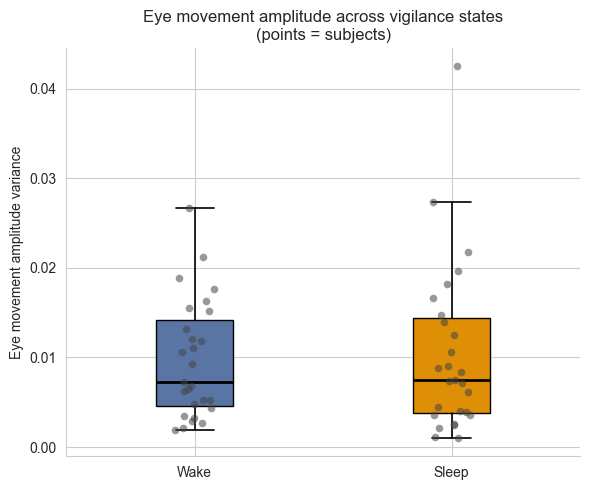

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def get_state_values(subject_blocks, label):
    subjects = list(subject_blocks.keys())
    result = []
    for s in subjects:
        blocks = [b for b, l in subject_blocks[s] if l == label]
        if len(blocks) > 0:
            result.append((s, np.std(np.concatenate(blocks))))
        else:
            result.append((s, np.nan))
    return result  # list of (subject, value) tuples, nan if no data


states = {"W": "Wake", "S": "Sleep"}
colors = {"W": "#5875a4ff", "S": "#de8f05ff"}

# Compute per-subject mean for each state
state_values = {}
for label in states:
    state_values[label] = {s: v for s, v in get_state_values(subject_blocks, label)}

fig, ax = plt.subplots(figsize=(6, 5))

# Boxplots
bp = ax.boxplot(
    [np.array([v for v in state_values[l].values() if not np.isnan(v)]) for l in states],
    positions=range(2),
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    zorder=2
)

for patch, label in zip(bp['boxes'], states):
    patch.set_facecolor(colors[label])
    patch.set_alpha(1)

# Per-subject lines
# subjects = list(subject_blocks_three_state.keys())
# for subject in subjects:
#     vals = [(j, state_values[l][subject]) for j, l in enumerate(states) 
#             if not np.isnan(state_values[l][subject])]
#     if len(vals) > 1:
#         positions, values = zip(*vals)
#         ax.plot(positions, values, color="gray", alpha=0.2, linewidth=0.8, zorder=1)

# Jittered subject points
for j, label in enumerate(states):
    valid = np.array([v for v in state_values[label].values() if not np.isnan(v)])
    jitter = np.random.uniform(-0.08, 0.08, len(valid))
    ax.scatter(
        np.full(len(valid), j) + jitter,
        valid,
        color="#4444448c", alpha=0.55, s=30, zorder=3,
        edgecolors='white', linewidths=0
    )

ax.set_xticks(range(2))
ax.set_xticklabels(states.values())
ax.set_ylabel("Eye movement amplitude variance")
ax.set_title("Eye movement amplitude across vigilance states\n(points = subjects)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig("/Users/zach/2025_RA/matthias/final images/eye_voxels/mean_amplitude_states.svg", dpi=300)


In [20]:
state_values["1"]

{'10': 0.002590767997577912,
 '22': 0.009650967707935458,
 '06': 0.029499410749208775,
 '18': 0.012417191118983454,
 '25': 0.0011451716859720233,
 '17': 0.008722207802605266,
 '33': 0.0068997518016486,
 '19': 0.009218452596746406,
 '24': 0.008681439737387161,
 '16': 0.008192567672560777,
 '32': 0.003966308955601666,
 '08': 0.01789288645240233,
 '11': 0.014093274118757403,
 '23': 0.005375845122226834,
 '26': 0.036206898437123644,
 '30': 0.004614467423960827,
 '14': 0.009623525687380974,
 '29': 0.01722594485208794,
 '13': 0.03424293833554806,
 '05': 0.00392500532150005,
 '04': 0.009714075703381475,
 '20': 0.005665993488943696,
 '27': 0.009318891715818824,
 '03': 0.005687322098186317,
 '31': 0.01657218507140831,
 '15': 0.0019184325000459392,
 '28': 0.003331779652835682}

In [117]:
from scipy.stats import f_oneway
from scipy.stats import ttest_1samp

from scipy.stats import zscore
import numpy as np

    
    

def compute_f_statistic(blocks):
    wake = np.concatenate([b for b, l in blocks if l == "W"])
    n1   = np.concatenate([b for b, l in blocks if l == "1"])
    n2   = np.concatenate([b for b, l in blocks if l == "2"])
    # Skip subjects missing a state
    if len(wake) == 0 or len(n1) == 0 or len(n2) == 0:
        return np.nan
    return f_oneway(wake, n1, n2).statistic

def permutation_f_test_pseudoz(subject_blocks, n_permutations=1000):
    subjects = list(subject_blocks.keys())
    
    subject_zs = []
    for subject in subjects:
        blocks = subject_blocks[subject]
        
        observed_f = compute_f_statistic(blocks)
        if np.isnan(observed_f):
            continue
        
        null_fs = [compute_f_statistic(permute_labels(blocks)) 
                   for _ in range(n_permutations)]
        
        null_mean = np.mean(null_fs)
        null_std = np.std(null_fs)
        subject_zs.append((observed_f - null_mean) / null_std)
    
    subject_zs = np.array(subject_zs)
    t_stat, p_value = ttest_1samp(subject_zs, popmean=0)
    
    return {
        "subject_zs": subject_zs,
        "group_z": np.mean(subject_zs),
        "t_stat": t_stat,
        "p_value": p_value
    }

results_f = permutation_f_test_pseudoz(subject_blocks_three_state)
print(f"t = {results_f['t_stat']:.4f}, p = {results_f['p_value']:.4f}")

t = 1.8590, p = 0.0786


In [52]:

def compute_statistic(blocks, stat):
    """
    Compute statistic per subject
    Find the difference in descriptors for each state using all 
    contiguous state blocks across runs 
    Parameters
    ----------
    blocks
    stat

    Returns
    -------

    """
    wake_vals = np.concatenate([b for b, l in blocks if l == l1])
    sleep_vals = np.concatenate([b for b, l in blocks if l == l2])
    if stat == "mean":
        return np.mean(wake_vals) - np.mean(sleep_vals)
    elif stat == "var":
        return np.var(wake_vals) - np.var(sleep_vals)
    elif stat == "median":
        return np.median(wake_vals) - np.median(sleep_vals)
    elif stat == "iqr":
        return np.percentile(wake_vals, 75) - np.percentile(sleep_vals, 25)

def permute_labels(blocks):
    labels = [l for _, l in blocks]
    np.random.shuffle(labels)
    return [(b, l) for (b, _), l in zip(blocks, labels)]

def permutation_test2(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subj_zs = []
    for subject in subjects:
        subj_null_distribution = []
        for _ in range(n_permutations):
            perm_stats = np.array([
                compute_statistic(permute_labels(subject_blocks[subject]), stat) 
            ])
            subj_null_distribution.append(np.mean(perm_stats))
        shuffled_mean = np.mean(subj_null_distribution)
        shuffled_std = np.std(subj_null_distribution)
        observed_mean = compute_statistic(subject_blocks[subject], stat)
        
        subj_z = (observed_mean - shuffled_mean) / shuffled_std
        subj_zs.append(subj_z)
    return np.mean(subj_zs), subj_zs

def permutation_test(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    # Observed subject-level statistics
    observed = np.array([compute_statistic(subject_blocks[s], stat) for s in subjects])
    observed_group = np.mean(observed)
    
    # Permutation distribution
    null_distribution = []
    for _ in range(n_permutations):
        perm_stats = np.array([
            compute_statistic(permute_labels(subject_blocks[s]), stat) 
            for s in subjects
        ])
        null_distribution.append(np.mean(perm_stats))
    
    null_distribution = np.array(null_distribution)
    p_value = np.mean(np.abs(null_distribution) >= np.abs(observed_group))
    
    return {
        "observed_group": observed_group,
        "observed_per_subject": dict(zip(subjects, observed)),
        "null_distribution": null_distribution,
        "p_value": p_value,
    }

from scipy.stats import f_oneway

# Run tests
# results_mean = permutation_test(subject_blocks, stat="mean", n_permutations=10000)
# results_median = permutation_test(subject_blocks, stat="median", n_permutations=10000)
# results_var  = permutation_test(subject_blocks, stat="var", n_permutations=10000)

mean_zs, zs  = permutation_test2(subject_blocks, stat="iqr", n_permutations=10000)


In [53]:
mean_zs

0.04288980875870764

In [54]:
from scipy.stats import ttest_1samp

ttest_1samp(zs, 0, alternative="two-sided")

# print(f"{mean_zs:.4f}")
# print(zs)

TtestResult(statistic=0.1474655502139867, pvalue=0.8839021841397292, df=26)

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_ylabel'

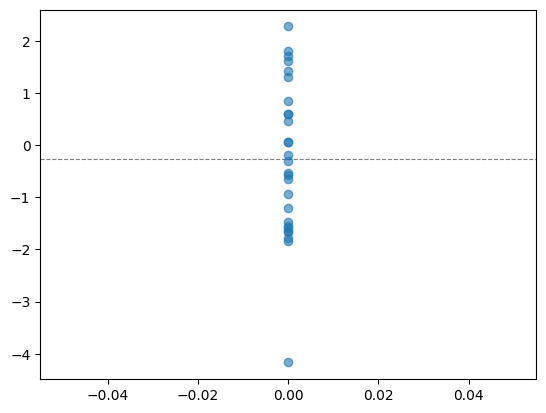

In [100]:

plt.axhline(np.mean(zs), color='gray', linestyle='--', linewidth=0.8)
plt.plot(np.zeros(len(zs)), zs, 'o', alpha=0.6)
plt.set_ylabel(f"{l1} - {l2} {stat} amplitude")
plt.set_title("Per-subject differences")

In [67]:

print(f"Mean amplitude: {l1}-{l2} = {results_mean['observed_group']:.4f}, p = {results_mean['p_value']:.4f}")
print(f"Variance:      {l1}-{l2} = {results_var['observed_group']:.4f},  p = {results_var['p_value']:.4f}")
print(f"Median:       {l1}-{l2} = {results_median['observed_group']:.4f},  p = {results_median['p_value']:.4f}")

Mean amplitude: W-1 = -0.0021, p = 0.0003
Variance:      W-1 = -0.0001,  p = 0.0064
Median:       W-1 = -0.0021,  p = 0.0000


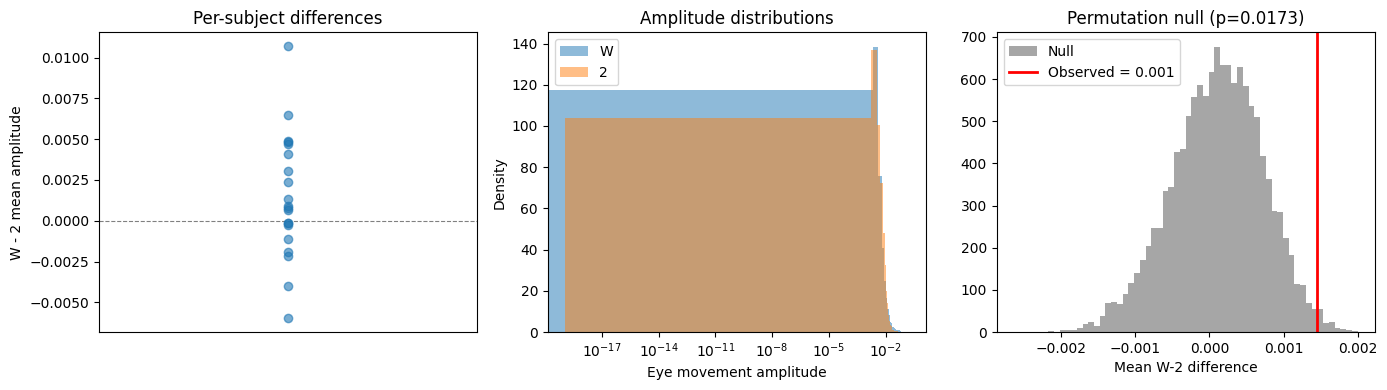

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

stat = "mean"
result = results_mean


# 1. Per-subject W-S mean differences (paired)
subjects = list(subject_blocks.keys())
per_subject = np.array([compute_statistic(subject_blocks[s], stat) for s in subjects])

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].plot(np.zeros(len(per_subject)), per_subject, 'o', alpha=0.6)
axes[0].set_xticks([])
axes[0].set_ylabel(f"{l1} - {l2} {stat} amplitude")
axes[0].set_title("Per-subject differences")

# 2. Distribution of pooled wake vs sleep values across all subjects
all_wake = np.concatenate([
    np.concatenate([b for b, l in subject_blocks[s] if l == l1]) for s in subjects
])
all_sleep = np.concatenate([
    np.concatenate([b for b, l in subject_blocks[s] if l == l2]) for s in subjects
])

axes[1].hist(all_wake, bins=80, alpha=0.5, label=l1, density=True)
axes[1].hist(all_sleep, bins=80, alpha=0.5, label=l2, density=True)
axes[1].set_xlabel("Eye movement amplitude")
axes[1].set_ylabel("Density")
axes[1].set_title("Amplitude distributions")
# axes[1].set_xscale('log')
axes[1].legend()

# 3. Null distribution with observed statistic
axes[2].hist(result["null_distribution"], bins=60, density=True, 
             color='gray', alpha=0.7, label="Null")
axes[2].axvline(result["observed_group"], color='red', 
                linewidth=2, label=f"Observed = {result['observed_group']:.3f}")
axes[2].set_xlabel(f"{stat.capitalize()} {l1}-{l2} difference")
axes[2].set_title(f"Permutation null (p={result['p_value']:.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()

In [70]:
subjects = list(subject_blocks.keys())
all_wake = np.concatenate([np.concatenate([b for b, l in subject_blocks[s] if l == l1]) for s in subjects])
all_sleep = np.concatenate([np.concatenate([b for b, l in subject_blocks[s] if l == l2]) for s in subjects])

print(f"{l1} mean: {np.mean(all_wake):.4f}, {l2} mean: {np.mean(all_sleep):.4f}")
print(f"{l1} median: {np.median(all_wake):.4f}, {l2} median: {np.median(all_sleep):.4f}")
print(f"{l1} var: {np.var(all_wake):.6f}, {l2} var: {np.var(all_sleep):.6f}")

W mean: 0.0091, 1 mean: 0.0084
W median: 0.0046, 1 median: 0.0051
W var: 0.000184, 1 var: 0.000141


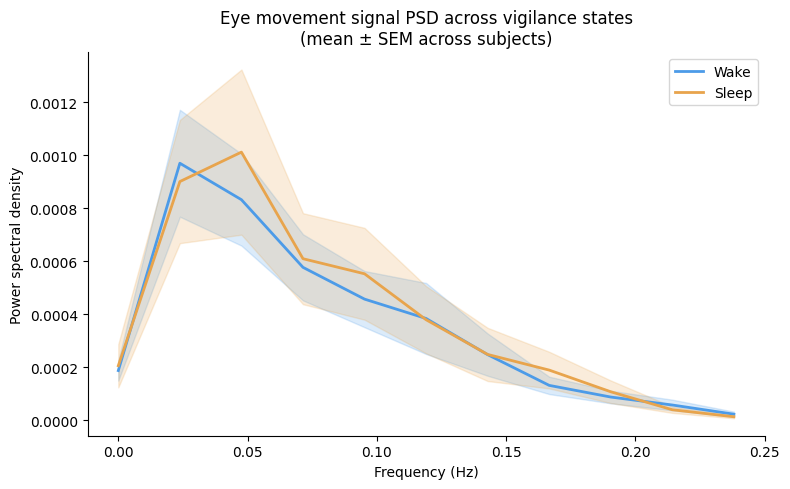

In [124]:


from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

TR = mrio.tr  # 2.1s
fs = 1 / TR   # ~0.476 Hz
min_block_len = 20

def get_state_psds(subject_blocks, label, fs, min_block_len=20):
    nperseg = min_block_len  # fixed window size, same for all blocks
    
    subject_psds = []
    subjects = list(subject_blocks.keys())
    
    for s in subjects:
        blocks = [b for b, l in subject_blocks[s] 
                  if l == label and len(b) >= nperseg]
        if len(blocks) == 0:
            subject_psds.append(None)
            continue
        
        block_psds = []
        for block in blocks:
            freqs, psd = welch(block, fs=fs, nperseg=nperseg)
            block_psds.append(psd)
        
        subject_psds.append(np.mean(block_psds, axis=0))
    
    return freqs, subject_psds

states = {"W": "Wake", "S": "Sleep"} #, "2": "2"}
colors = {"W": "#4C9BE8", "S": "#E8A44C"} #, "2": "#6DBE6D"}

fig, ax = plt.subplots(figsize=(8, 5))

for label, state_name in states.items():
    freqs, subject_psds = get_state_psds(
        subject_blocks, label, fs, min_block_len
    )
    
    # Filter out subjects with no data
    valid_psds = np.array([p for p in subject_psds if p is not None])
    
    mean_psd = np.mean(valid_psds, axis=0)
    sem_psd  = stats.sem(valid_psds, axis=0)
    
    ax.plot(freqs, mean_psd, color=colors[label], label=state_name, linewidth=2)
    ax.fill_between(freqs, 
                    mean_psd - sem_psd, 
                    mean_psd + sem_psd, 
                    color=colors[label], alpha=0.2)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power spectral density")
ax.set_title("Eye movement signal PSD across vigilance states\n(mean ± SEM across subjects)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [122]:
mrio.load
for label, state_name in states.items():
    block_lengths = [
        len(b) for s in subject_blocks_three_state
        for b, l in subject_blocks_three_state[s]
        if l == label and len(b) >= min_block_len
    ]
    print(f"{state_name}: n_blocks={len(block_lengths)}, "
          f"mean_length={np.mean(block_lengths):.1f}, "
          f"median_length={np.median(block_lengths):.1f}")
    

Wake: n_blocks=164, mean_length=119.1, median_length=55.0
1: n_blocks=239, mean_length=64.7, median_length=41.0
2: n_blocks=125, mean_length=89.5, median_length=56.0


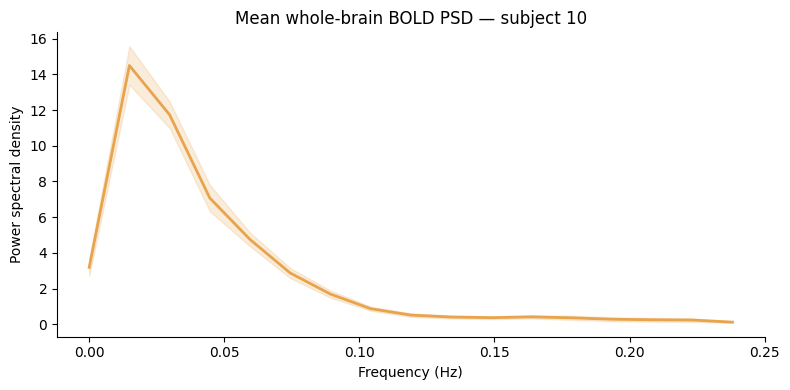

In [128]:
import nibabel as nib
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

subject = mrio.subjects[0]
TR = mrio.tr
fs = 1 / TR

all_run_psds = []

for _, run, run_df in mrio.iter_run_events(subject=subject):
    # Load functional image
    img, _ = mrio.load_functional_image(subject, run)
    data = img.get_fdata()  # shape: (x, y, z, TRs)
    
    # Mean signal across all voxels per TR
    mean_signal = data.mean(axis=(0, 1, 2))  # shape: (TRs,)
    
    # Compute PSD
    freqs, psd = welch(mean_signal, fs=fs, nperseg=min(len(mean_signal), 32))
    all_run_psds.append(psd)

# Average across runs
# mean_psd = np.mean(all_run_psds, axis=0)
    
mean_psd = np.mean(all_run_psds, axis=0)
sem_psd  = stats.sem(all_run_psds, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(freqs, mean_psd, color=colors[label], label=state_name, linewidth=2)
ax.fill_between(freqs, 
                mean_psd - sem_psd, 
                mean_psd + sem_psd, 
                color=colors[label], alpha=0.2)
# ax.plot(freqs, mean_psd, linewidth=2)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power spectral density")
ax.set_title(f"Mean whole-brain BOLD PSD — subject {subject}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()